<a href="https://colab.research.google.com/github/hassan1662n/Deep-learning-projects/blob/main/Oxford_Pet_dataset_m1_cat_vs_dog_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget -q http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget -q http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

In [2]:
!mkdir -p /content/pets
!tar -xzf images.tar.gz -C /content/pets
!tar -xzf annotations.tar.gz -C /content/pets

In [3]:
!find /content/pets -maxdepth 2 -type f | head -30

/content/pets/annotations/README
/content/pets/annotations/trainval.txt
/content/pets/annotations/._trimaps
/content/pets/annotations/list.txt
/content/pets/annotations/test.txt
/content/pets/images/Sphynx_198.jpg
/content/pets/images/Sphynx_29.jpg
/content/pets/images/Bombay_47.jpg
/content/pets/images/japanese_chin_19.jpg
/content/pets/images/samoyed_176.jpg
/content/pets/images/Abyssinian_116.jpg
/content/pets/images/Egyptian_Mau_207.jpg
/content/pets/images/newfoundland_92.jpg
/content/pets/images/miniature_pinscher_104.jpg
/content/pets/images/Russian_Blue_118.jpg
/content/pets/images/staffordshire_bull_terrier_68.jpg
/content/pets/images/pomeranian_172.jpg
/content/pets/images/american_pit_bull_terrier_102.jpg
/content/pets/images/basset_hound_162.jpg
/content/pets/images/Persian_270.jpg
/content/pets/images/miniature_pinscher_3.jpg
/content/pets/images/havanese_155.jpg
/content/pets/images/staffordshire_bull_terrier_127.jpg
/content/pets/images/leonberger_175.jpg
/content/pets/i

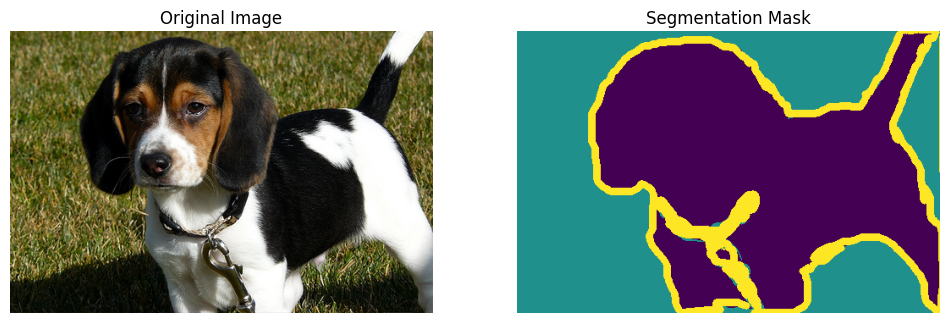

In [4]:
from PIL import Image
import matplotlib.pyplot as plt
import glob
import os

image_path = "/content/pets/images/beagle_148.jpg"

# Corresponding mask
mask_path = "/content/pets/annotations/trimaps/beagle_148.png"

image = Image.open(image_path)
mask = Image.open(mask_path)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.title("Segmentation Mask")
plt.axis("off")

plt.show()

In [43]:
df = pd.DataFrame(columns=['image_path', 'species', 'breed'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7390 entries, 0 to 7389
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  7390 non-null   object
 1   mask_path   7390 non-null   object
 2   breed       7390 non-null   object
 3   species     7390 non-null   object
dtypes: object(4)
memory usage: 231.1+ KB


In [7]:
df.head()

,image_path,mask_path,breed,species
0,/content/pets/images/Sphynx_198.jpg,/content/pets/annotations/trimaps/Sphynx_198.png,Sphynx,cat
1,/content/pets/images/Sphynx_29.jpg,/content/pets/annotations/trimaps/Sphynx_29.png,Sphynx,cat
2,/content/pets/images/Bombay_47.jpg,/content/pets/annotations/trimaps/Bombay_47.png,Bombay,cat
3,/content/pets/images/japanese_chin_19.jpg,/content/pets/annotations/trimaps/japanese_chi...,japanese_chin,dog
4,/content/pets/images/samoyed_176.jpg,/content/pets/annotations/trimaps/samoyed_176.png,samoyed,dog


In [8]:
df['species'].value_counts()

,count
species,
dog,5190
cat,2200


In [9]:
df['breed'].value_counts()

,count
breed,
Sphynx,200
Bombay,200
japanese_chin,200
samoyed,200
Abyssinian,200
Egyptian_Mau,200
newfoundland,200
miniature_pinscher,200
Russian_Blue,200


In [10]:
df.shape

(7390, 4)

In [11]:
print(len(df['breed'].unique()))

37


In [12]:
from PIL import Image
import numpy as np
print(np.array(Image.open(df['image_path'][11])).shape)

(150, 200, 3)


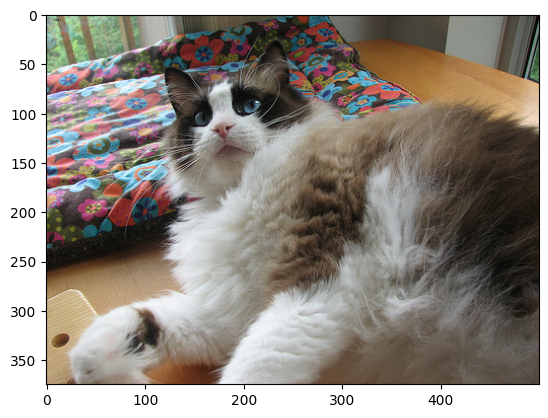

In [13]:
plt.imshow(Image.open(df['image_path'][24]))

In [14]:
df.sample(10)

,image_path,mask_path,breed,species
1169,/content/pets/images/leonberger_144.jpg,/content/pets/annotations/trimaps/leonberger_1...,leonberger,dog
3132,/content/pets/images/samoyed_150.jpg,/content/pets/annotations/trimaps/samoyed_150.png,samoyed,dog
143,/content/pets/images/Maine_Coon_27.jpg,/content/pets/annotations/trimaps/Maine_Coon_2...,Maine_Coon,dog
2409,/content/pets/images/Maine_Coon_152.jpg,/content/pets/annotations/trimaps/Maine_Coon_1...,Maine_Coon,dog
2507,/content/pets/images/shiba_inu_58.jpg,/content/pets/annotations/trimaps/shiba_inu_58...,shiba_inu,dog
3406,/content/pets/images/english_setter_46.jpg,/content/pets/annotations/trimaps/english_sett...,english_setter,dog
6374,/content/pets/images/yorkshire_terrier_8.jpg,/content/pets/annotations/trimaps/yorkshire_te...,yorkshire_terrier,dog
98,/content/pets/images/Egyptian_Mau_156.jpg,/content/pets/annotations/trimaps/Egyptian_Mau...,Egyptian_Mau,cat
7059,/content/pets/images/great_pyrenees_2.jpg,/content/pets/annotations/trimaps/great_pyrene...,great_pyrenees,dog
1836,/content/pets/images/shiba_inu_93.jpg,/content/pets/annotations/trimaps/shiba_inu_93...,shiba_inu,dog


In [15]:
cats = df[df["species"] == "cat"]
dogs = df[df["species"] == "dog"]

cats_sample = cats.sample(n=2200, random_state=42)
dogs_sample = dogs.sample(n=2200, random_state=42)

balanced_df = pd.concat([cats_sample, dogs_sample])

balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [16]:
print(balanced_df.shape)
balanced_df.head()

(4400, 4)


,image_path,mask_path,breed,species
0,/content/pets/images/Persian_77.jpg,/content/pets/annotations/trimaps/Persian_77.png,Persian,cat
1,/content/pets/images/staffordshire_bull_terrie...,/content/pets/annotations/trimaps/staffordshir...,staffordshire_bull_terrier,dog
2,/content/pets/images/staffordshire_bull_terrie...,/content/pets/annotations/trimaps/staffordshir...,staffordshire_bull_terrier,dog
3,/content/pets/images/Siamese_139.jpg,/content/pets/annotations/trimaps/Siamese_139.png,Siamese,cat
4,/content/pets/images/Siamese_119.jpg,/content/pets/annotations/trimaps/Siamese_119.png,Siamese,cat


In [17]:
balanced_df['species'].value_counts()

,count
species,
cat,2200
dog,2200


In [18]:
X = balanced_df['image_path']
Y = balanced_df['species'].replace({'cat': 0, 'dog': 1})

/tmp/ipykernel_539/27464099.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y = balanced_df['species'].replace({'cat': 0, 'dog': 1})


In [19]:
print(X)
print(Y)

0                     /content/pets/images/Persian_77.jpg
1       /content/pets/images/staffordshire_bull_terrie...
2       /content/pets/images/staffordshire_bull_terrie...
3                    /content/pets/images/Siamese_139.jpg
4                    /content/pets/images/Siamese_119.jpg
                              ...                        
4395       /content/pets/images/yorkshire_terrier_109.jpg
4396                 /content/pets/images/Siamese_225.jpg
4397                      /content/pets/images/pug_99.jpg
4398    /content/pets/images/english_cocker_spaniel_56...
4399                  /content/pets/images/Persian_86.jpg
Name: image_path, Length: 4400, dtype: object
0       0
1       1
2       1
3       0
4       0
       ..
4395    1
4396    0
4397    1
4398    1
4399    0
Name: species, Length: 4400, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test , Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [21]:
print(X.shape, X_train.shape, X_test.shape)

(4400,) (3520,) (880,)


In [22]:
print(X_train[1])

/content/pets/images/staffordshire_bull_terrier_22.jpg


In [23]:
import tensorflow as tf

IMG_SIZE = (224, 224)

def preprocess_image(path, label):
    # Read image file
    image = tf.io.read_file(path)

    # Decode image
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Resize
    image = tf.image.resize(image, IMG_SIZE)

    # Convert 0-255 → 0-1
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [24]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, Y_train)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, Y_test)
)

In [25]:
train_ds = train_ds.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [26]:
BATCH_SIZE = 32

train_ds = train_ds.shuffle(len(X_train))
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [27]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Image data type:", images.dtype)
    print("Image minimum:", tf.reduce_min(images).numpy())
    print("Image maximum:", tf.reduce_max(images).numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Image data type: <dtype: 'float32'>
Image minimum: 0.0
Image maximum: 1.0


In [28]:
for images, labels in train_ds.take(1):
    print(labels.numpy())

[1 1 1 1 1 1 1 0 0 0 0 1 0 1 0 1 0 0 1 0 1 0 0 0 1 0 1 0 1 1 0 0]


In [36]:
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense

In [37]:
model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

# Block 4
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

# Classification
model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Cat / Dog
model.add(Dense(2, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=40
)

Epoch 1/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 38s 127ms/step - accuracy: 0.5591 - loss: 0.8649 - val_accuracy: 0.4932 - val_loss: 0.7062
Epoch 2/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - accuracy: 0.5773 - loss: 0.7510 - val_accuracy: 0.4886 - val_loss: 0.7210
Epoch 3/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 16s 89ms/step - accuracy: 0.5929 - loss: 0.7273 - val_accuracy: 0.5091 - val_loss: 0.9795
Epoch 4/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - accuracy: 0.6062 - loss: 0.6866 - val_accuracy: 0.5148 - val_loss: 0.8470
Epoch 5/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - accuracy: 0.6074 - loss: 0.6825 - val_accuracy: 0.6205 - val_loss: 0.6499
Epoch 6/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - accuracy: 0.6347 - loss: 0.6545 - val_accuracy: 0.5795 - val_loss: 0.6751
Epoch 7/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - accuracy: 0.6321 - loss: 0.6479 - val_accuracy: 0.5830 - val_loss: 0.7355
Epoch 8/40
110/110 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - accuracy: 0.6500 - loss: 0.6368 -

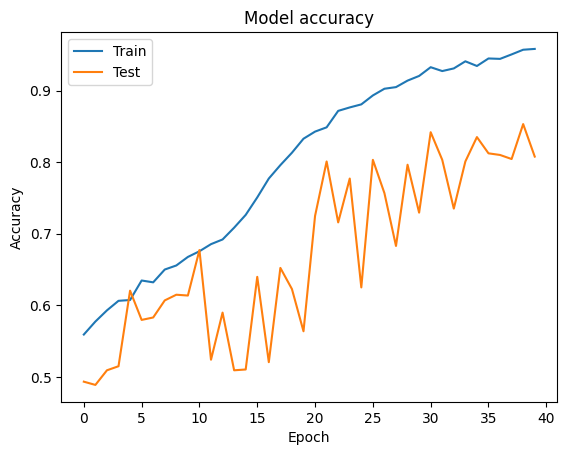

In [41]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

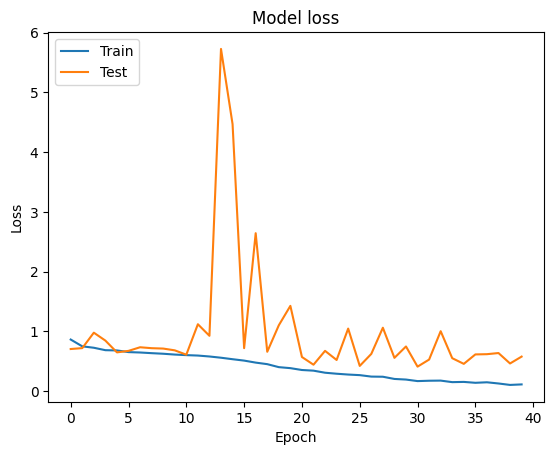

In [42]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')


In [44]:
print("Training:")
print(Y_train.value_counts())

print("\nTest:")
print(Y_test.value_counts())

Training:
species
1    1768
0    1752
Name: count, dtype: int64

Test:
species
0    448
1    432
Name: count, dtype: int64


In [45]:
import numpy as np

for images, labels in test_ds.take(1):

    predictions = model.predict(images)

    print("True labels:")
    print(labels.numpy())

    print("\nPredicted probabilities:")
    print(predictions.flatten())

    print("\nPredicted labels:")
    print((predictions.flatten() >= 0.5).astype(int))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
True labels:
[1 1 1 1 0 0 1 1 0 1 0 1 0 0 1 1 1 1 0 1 0 1 0 1 0 0 0 1 1 0 0 1]

Predicted probabilities:
[7.47237122e-04 9.99252737e-01 4.63489629e-03 9.95365143e-01
 8.22061241e-01 1.77938744e-01 7.97141939e-02 9.20285821e-01
 9.84318495e-01 1.56815015e-02 9.98245955e-01 1.75405492e-03
 4.35713725e-03 9.95642900e-01 2.30120599e-01 7.69879460e-01
 1.08105734e-01 8.91894281e-01 8.24710168e-03 9.91752923e-01
 9.99974012e-01 2.59721874e-05 2.31296599e-05 9.99976873e-01
 8.57867002e-01 1.42133027e-01 9.99723971e-01 2.76068662e-04
 1.47655690e-02 9.85234380e-01 2.22830669e-04 9.99777079e-01
 4.21544864e-05 9.99957800e-01 3.57400954e-01 6.42599106e-01
 9.99298573e-01 7.01392244e-04 5.06723046e-01 4.93276983e-01
 9.99918461e-01 8.15477033e-05 8.07452023e-01 1.92547962e-01
 5.86723804e-01 4.13276196e-01 1.29095523e-03 9.98709083e-01
 9.04847860e-01 9.51521322e-02 9.94358003e-01 5.64203970e-03
 9.99175608e-01 8.24359886e-04 9.68159526e-04 9.99031901e-01
 1

In [46]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    # Correctly get the predicted class by taking the argmax of the softmax output
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

print(cm)
print()
print(classification_report(
    y_true,
    y_pred,
    target_names=["Cat", "Dog"]
))

[[389  59]
 [110 322]]

              precision    recall  f1-score   support

         Cat       0.78      0.87      0.82       448
         Dog       0.85      0.75      0.79       432

    accuracy                           0.81       880
   macro avg       0.81      0.81      0.81       880
weighted avg       0.81      0.81      0.81       880



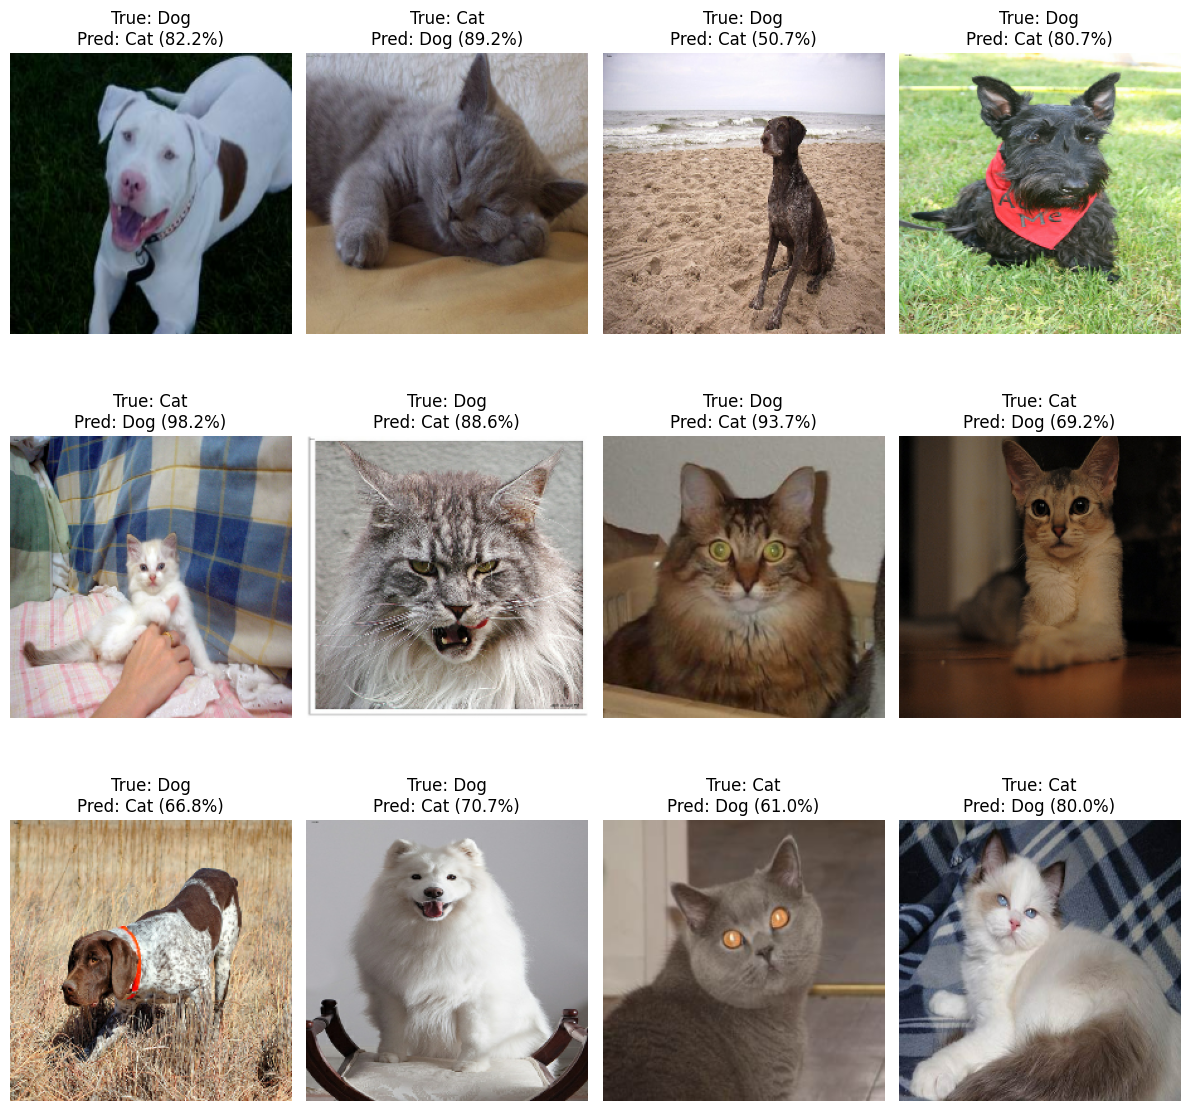

In [47]:
import matplotlib.pyplot as plt
import numpy as np

wrong_images = []
wrong_true = []
wrong_pred = []
wrong_conf = []

# Go through validation dataset
for images, labels in test_ds:

    # Get raw probabilities (batch_size, 2)
    predictions_raw = model.predict(images, verbose=0)

    # Get predicted class (0 or 1) for each image (batch_size,)
    predicted_labels = np.argmax(predictions_raw, axis=1)

    # Get true labels (batch_size,)
    true_labels = labels.numpy()

    # Find incorrect predictions
    wrong = predicted_labels != true_labels

    for i in np.where(wrong)[0]:
        wrong_images.append(images[i].numpy())
        wrong_true.append(true_labels[i])
        wrong_pred.append(predicted_labels[i])
        # Store the confidence for the predicted class
        wrong_conf.append(predictions_raw[i, predicted_labels[i]])


# Display first 12 wrong predictions
plt.figure(figsize=(12, 12))

for i in range(min(12, len(wrong_images))):

    plt.subplot(3, 4, i + 1)

    plt.imshow(wrong_images[i])

    true_label = "Dog" if wrong_true[i] == 1 else "Cat"
    pred_label = "Dog" if wrong_pred[i] == 1 else "Cat"

    # Confidence is already the probability of the predicted class
    confidence = wrong_conf[i]

    plt.title(
        f"True: {true_label}\n"
        f"Pred: {pred_label} ({confidence:.1%})"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [48]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

y_true = []
y_pred = []
y_confidence = []
all_images = []

for images, labels in test_ds:
    # Get raw probabilities (batch_size, 2)
    predictions_raw = model.predict(images, verbose=0)

    # Get predicted class (0 or 1) for each image (batch_size,)
    predicted_labels = np.argmax(predictions_raw, axis=1)

    # Get true labels (batch_size,)
    true_labels = labels.numpy()

    y_true.extend(true_labels)
    y_pred.extend(predicted_labels)

    # Store the confidence for the predicted class
    confidence = predictions_raw[np.arange(len(predicted_labels)), predicted_labels]
    y_confidence.extend(confidence)

    all_images.extend(images.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_confidence = np.array(y_confidence)
all_images = np.array(all_images)

print("Total validation images:", len(y_true))
print("Correct:", np.sum(y_true == y_pred))
print("Wrong:", np.sum(y_true != y_pred))
print("Accuracy:", np.mean(y_true == y_pred))

Total validation images: 880
Correct: 711
Wrong: 169
Accuracy: 0.8079545454545455


In [49]:
wrong_indices = np.where(y_true != y_pred)[0]

print("Number of wrong predictions:", len(wrong_indices))

Number of wrong predictions: 169


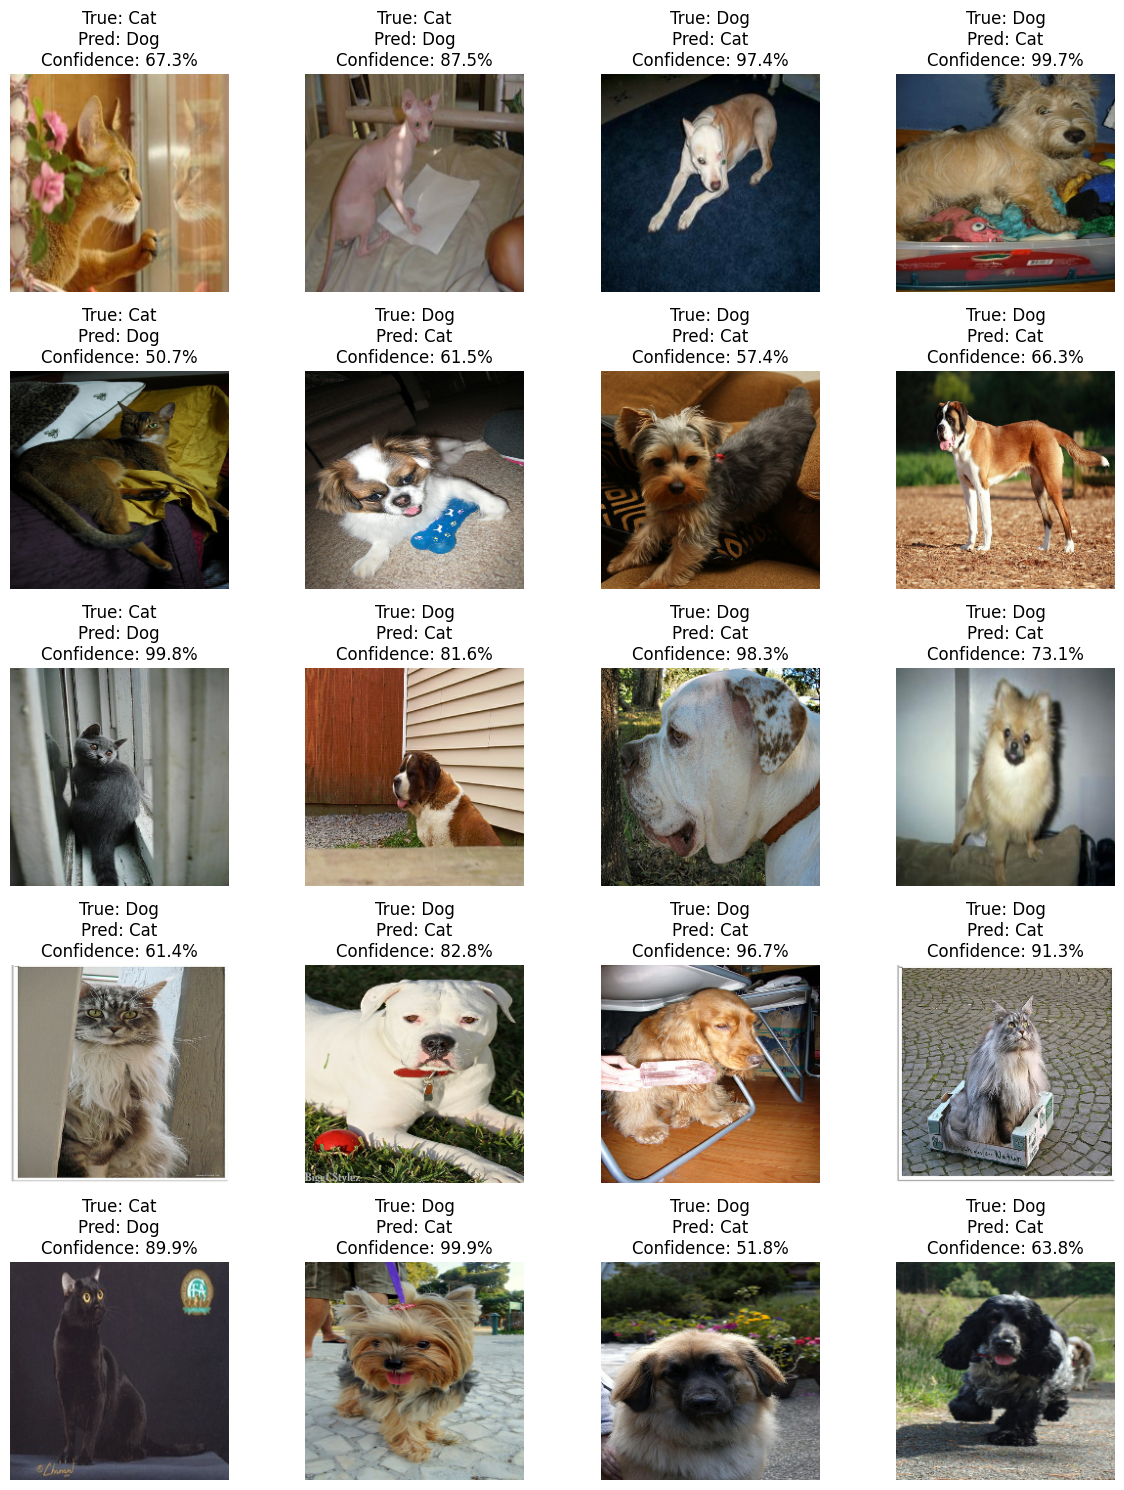

In [50]:
# Randomly select 20 wrong predictions
num_images = min(20, len(wrong_indices))

random_wrong = np.random.choice(
    wrong_indices,
    size=num_images,
    replace=False
)

plt.figure(figsize=(12, 15))

for plot_number, i in enumerate(random_wrong):

    plt.subplot(5, 4, plot_number + 1)

    plt.imshow(all_images[i])

    true_label = "Dog" if y_true[i] == 1 else "Cat"
    predicted_label = "Dog" if y_pred[i] == 1 else "Cat"

    plt.title(
        f"True: {true_label}\n"
        f"Pred: {predicted_label}\n"
        f"Confidence: {y_confidence[i]:.1%}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()